# Inverse PINN for a 1D hyperelastic bar: identification of Young's modulus

This notebook solves an inverse hyperelasticity problem on the reference interval

$$
X\in[0,L], \qquad L=1.
$$

The manufactured displacement is

$$
u(X)=aX(1-X),
$$

with the boundary conditions

$$
u(0)=0, \qquad u(1)=0.
$$

The material is described by the Saint-Venant--Kirchhoff energy

$$
W=\frac{1}{2}E E_{\mathrm{GL}}^2,
\qquad
E_{\mathrm{GL}}=\frac{1}{2}(F^2-1),
\qquad
F=1+\frac{\mathrm du}{\mathrm dX}.
$$

The first Piola--Kirchhoff stress and equilibrium equation are

$$
P=\frac{\partial W}{\partial F}=E E_{\mathrm{GL}}F,
\qquad
\frac{\mathrm dP}{\mathrm dX}+B=0.
$$

Young's modulus $E$ is unknown and is optimized together with the neural-network parameters. Displacement observations are therefore always included. `USE_NOISY_DATA` is the only data-mode switch: `False` uses exact observations and `True` adds Gaussian noise.

The random observation sets are nested. For a fixed seed, increasing `N_DATA_TRAIN`, `N_DATA_VALIDATION`, or `N_DATA_TEST` selects a longer prefix of the same fixed master pool. Consequently, every smaller set is a subset of every larger set, including the associated noise realizations.

## 1. Imports

In [15]:
import copy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

OUTPUT_DIR = Path("imgs")
OUTPUT_DIR.mkdir(exist_ok=True)

## 2. Settings

The physical, discretization, network, and optimizer settings follow the forward notebook. The hidden value `E_TRUE` is used only to manufacture the body force and synthetic reference data. Optimization starts from `E_INITIAL`.

The amplitude must satisfy $0<a<1$ so that the exact deformation gradient remains positive. To compare different data counts while preserving nested data sets, change only the `N_DATA_*` values and keep the master-pool sizes and random seeds fixed.

In [ ]:
USE_NOISY_DATA = True
NOISE_RELATIVE_STD = 0.02

L = 1.0
E_TRUE = 1.0
E_INITIAL = 2.0
A = 0.2

N_PDE_TRAIN = 1000
N_PDE_VALIDATION = 100
N_PDE_TEST = 100
PDE_BATCH_SIZE = 16

N_DATA_TRAIN = 15
N_DATA_VALIDATION = 7
N_DATA_TEST = 7

MAX_N_DATA_TRAIN = 100
MAX_N_DATA_VALIDATION = 50
MAX_N_DATA_TEST = 50


EPOCHS = 2000
LBFGS_EPOCHS = 100
ADAM_EPOCHS = EPOCHS - LBFGS_EPOCHS
LR = 1e-3
SEED = 42

torch.manual_seed(SEED)
print(f"Minimum exact deformation gradient: {1.0 - A:.3f}")
print(f"True Young's modulus (synthetic reference only): {E_TRUE:.3f}")
print(f"Initial Young's modulus estimate: {E_INITIAL:.3f}")
print(f"Use noisy displacement data: {USE_NOISY_DATA}")
if USE_NOISY_DATA:
    print(f"Relative noise standard deviation: {NOISE_RELATIVE_STD:.1%}")

Minimum exact deformation gradient: 0.800
True Young's modulus (synthetic reference only): 1.000
Initial Young's modulus estimate: 2.000
Use noisy displacement data: True
Relative noise standard deviation: 2.0%


## 3. Exact solution and manufactured body force

For

$$
u(X)=aX(1-X),
$$

the exact deformation gradient is

$$
F(X)=1+a(1-2X).
$$

Since

$$
P=\frac{E}{2}(F^3-F),
$$

the body force required by equilibrium is

$$
B(X)=-\frac{\mathrm dP}{\mathrm dX}
=aE_{\mathrm{true}}\left(3F^2-1\right).
$$

`E_TRUE` is used here only to construct a consistent synthetic inverse problem. During training, the residual uses the fixed known body force above but computes the stress with the trainable estimate $E_\theta$.

In [17]:
def exact_displacement(x):
    return A * x * (L - x)


def exact_deformation_gradient(x):
    return 1.0 + A * (L - 2.0 * x)


def exact_green_lagrange_strain(x):
    F = exact_deformation_gradient(x)
    return 0.5 * (F**2 - 1.0)


def exact_nominal_stress(x):
    F = exact_deformation_gradient(x)
    return E_TRUE * exact_green_lagrange_strain(x) * F


def body_force(x):
    F = exact_deformation_gradient(x)
    return A * E_TRUE * (3.0 * F**2 - 1.0)

## 4. Neural network and unknown Young's modulus

The same neural network as in the forward notebook approximates the displacement $u_\theta(X)$. Young's modulus is one additional trainable scalar parameter,

$$
E_\theta\in\mathbb{R},
$$

initialized by `E_INITIAL`. It is stored inside the model, so both Adam and L-BFGS optimize it automatically and every checkpoint contains its value.

In [18]:
class InversePINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 1),
        )
        self.E = nn.Parameter(torch.tensor(E_INITIAL))

    def forward(self, x):
        return self.net(x)


model = InversePINN()
optimizer_adam = torch.optim.Adam(model.parameters(), lr=LR)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Initial trainable E: {model.E.item():.6f}")

Trainable parameters: 902
Initial trainable E: 2.000000


## 5. PDE train, validation, and test points

All three PDE sets are uniform interior grids with different within-cell shifts. The shifts make the training, validation, and test coordinates mutually disjoint. Training points update the network, validation points select the best checkpoint, and test points remain unused until the final evaluation.

In [19]:
def shifted_uniform_grid(number_of_points, shift):
    indices = torch.arange(number_of_points, dtype=torch.get_default_dtype())
    return (L * (indices + shift) / number_of_points).view(-1, 1)


def grids_overlap(first, second):
    distances = torch.abs(first[:, None, 0] - second[None, :, 0])
    return bool(torch.any(distances < 1e-12))


x_pde_train = shifted_uniform_grid(N_PDE_TRAIN, shift=0.50)
x_pde_validation = shifted_uniform_grid(N_PDE_VALIDATION, shift=0.37)
x_pde_test = shifted_uniform_grid(N_PDE_TEST, shift=0.73)

assert not grids_overlap(x_pde_train, x_pde_validation)
assert not grids_overlap(x_pde_train, x_pde_test)
assert not grids_overlap(x_pde_validation, x_pde_test)

print(f"PDE points: {N_PDE_TRAIN} train, {N_PDE_VALIDATION} validation, {N_PDE_TEST} test")
print("PDE grids overlap: False")
print(f"Adam PDE batch size: {PDE_BATCH_SIZE}")

pde_batch_generator = torch.Generator().manual_seed(SEED + 1)
pde_train_loader = DataLoader(
    TensorDataset(x_pde_train),
    batch_size=PDE_BATCH_SIZE,
    shuffle=True,
    generator=pde_batch_generator,
)

PDE points: 1000 train, 100 validation, 100 test
PDE grids overlap: False
Adam PDE batch size: 16


## 6. Mandatory random nested displacement data

Displacement observations are always used because they make the material-parameter identification an inverse problem. All three data splits are random, mutually independent, and located strictly inside the domain.

Each split is generated once as a fixed master pool. The active data set consists of the first `N_DATA_*` point--noise pairs from that pool. Therefore, if a count is increased while its seed and `MAX_N_DATA_*` remain unchanged, the old observations are retained exactly and only new observations are added.

With `USE_NOISY_DATA = False`, the observations are exact. With `USE_NOISY_DATA = True`, fixed independent Gaussian noise is added with standard deviation

$$
s_{\mathrm{noise}}=0.02\max_X|u_{\mathrm{exact}}(X)|.
$$

In [20]:
def nested_random_displacement_data(
    number_of_points,
    maximum_number_of_points,
    location_seed,
    noise_seed,
):
    # Return a sorted prefix of a fixed random point-and-noise master pool.
    location_generator = torch.Generator().manual_seed(location_seed)
    noise_generator = torch.Generator().manual_seed(noise_seed)

    # Keep observations strictly inside the interval.
    margin = 1e-6 * L
    x_pool = margin + (L - 2.0 * margin) * torch.rand(
        maximum_number_of_points, 1, generator=location_generator
    )
    noise_pool = torch.randn(
        maximum_number_of_points, 1, generator=noise_generator
    )

    x = x_pool[:number_of_points].clone()
    noise = noise_pool[:number_of_points].clone()

    order = torch.argsort(x[:, 0])
    x = x[order]
    noise = noise[order]

    displacement = exact_displacement(x)
    if USE_NOISY_DATA:
        maximum_displacement = A * L**2 / 4.0
        displacement = (
            displacement
            + NOISE_RELATIVE_STD * maximum_displacement * noise
        )
    return x, displacement


x_data_train, u_data_train = nested_random_displacement_data(
    N_DATA_TRAIN,
    MAX_N_DATA_TRAIN,
    location_seed=SEED + 10,
    noise_seed=SEED + 20,
)
x_data_validation, u_data_validation = nested_random_displacement_data(
    N_DATA_VALIDATION,
    MAX_N_DATA_VALIDATION,
    location_seed=SEED + 11,
    noise_seed=SEED + 21,
)
x_data_test, u_data_test = nested_random_displacement_data(
    N_DATA_TEST,
    MAX_N_DATA_TEST,
    location_seed=SEED + 12,
    noise_seed=SEED + 22,
)

assert not grids_overlap(x_data_train, x_data_validation)
assert not grids_overlap(x_data_train, x_data_test)
assert not grids_overlap(x_data_validation, x_data_test)

data_mode_label = "noisy" if USE_NOISY_DATA else "exact"
print(
    f"Displacement data: {N_DATA_TRAIN} train, "
    f"{N_DATA_VALIDATION} validation, {N_DATA_TEST} test"
)
print(f"Displacement data mode: {data_mode_label}")
print("Random data splits overlap: False")
print("Nested-prefix sampling: enabled")

Displacement data: 15 train, 7 validation, 7 test
Displacement data mode: noisy
Random data splits overlap: False
Nested-prefix sampling: enabled


## 7. Physics residual and training

The network approximates $u_\theta(X)$ and the scalar parameter $E_\theta$ is optimized simultaneously. Automatic differentiation gives

$$
F_\theta=1+u_\theta',
\qquad
E_{\mathrm{GL},\theta}=\frac{1}{2}(F_\theta^2-1),
\qquad
P_\theta=E_\theta E_{\mathrm{GL},\theta}F_\theta.
$$

The PDE residual is

$$
r_\theta=P_\theta'+B,
$$

where $B$ is fixed and known; it is never recomputed from the current estimate $E_\theta$.

The training loss is unchanged in structure,

$$
\mathcal L_{\mathrm{train}}
=\mathcal L_{\mathrm{PDE}}
+\mathcal L_{\mathrm{BC}}
+\mathcal L_{\mathrm{data}},
$$

but the displacement-data term is now always present. During Adam training, the PDE points are shuffled and divided into mini-batches. The complete displacement dataset and both boundary points are used in every optimizer step. One epoch is one complete pass through all PDE training points. Validation, testing, and L-BFGS use fixed full batches. The best checkpoint, including the identified $E_\theta$, is selected by the combined validation PDE and data loss.

In [21]:
loss_history = []
pde_loss_history = []
bc_loss_history = []
data_loss_history = []
validation_loss_history = []
validation_pde_loss_history = []
validation_data_loss_history = []
E_history = []

best_validation_loss = float("inf")
best_validation_pde_loss = None
best_validation_data_loss = None
best_epoch = None
best_model_state = None


def displacement_stress_and_residual(x, create_graph):
    x_local = x.detach().clone().requires_grad_(True)
    u = model(x_local)
    du = torch.autograd.grad(
        u, x_local, torch.ones_like(u), create_graph=True
    )[0]
    F = 1.0 + du
    E_gl = 0.5 * (F**2 - 1.0)
    P = model.E * E_gl * F
    dP = torch.autograd.grad(
        P, x_local, torch.ones_like(P), create_graph=create_graph
    )[0]
    residual = dP + body_force(x_local)
    return u, P, residual


def compute_training_losses(x_pde):
    _, _, residual = displacement_stress_and_residual(x_pde, create_graph=True)
    loss_pde = torch.mean(residual**2)
    loss_bc = model(torch.tensor([[0.0]])).square().mean()
    loss_bc = loss_bc + model(torch.tensor([[L]])).square().mean()
    loss_data = torch.mean((model(x_data_train) - u_data_train)**2)
    loss = loss_pde + loss_bc + loss_data
    return loss, loss_pde, loss_bc, loss_data


def compute_validation_losses():
    _, _, residual = displacement_stress_and_residual(
        x_pde_validation, create_graph=False
    )
    loss_pde = torch.mean(residual.detach()**2)
    with torch.no_grad():
        loss_data = torch.mean(
            (model(x_data_validation) - u_data_validation)**2
        )
    return loss_pde + loss_data, loss_pde, loss_data


def update_checkpoint(epoch):
    global best_validation_loss, best_validation_pde_loss
    global best_validation_data_loss, best_epoch, best_model_state

    model.eval()
    loss, loss_pde, loss_data = compute_validation_losses()
    values = loss.item(), loss_pde.item(), loss_data.item()
    validation_loss_history.append(values[0])
    validation_pde_loss_history.append(values[1])
    validation_data_loss_history.append(values[2])
    E_history.append(model.E.detach().item())

    if best_model_state is None or values[0] < best_validation_loss:
        best_validation_loss = values[0]
        best_validation_pde_loss = values[1]
        best_validation_data_loss = values[2]
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())

    model.train()
    return values[0]


for epoch in range(ADAM_EPOCHS):
    epoch_sums = np.zeros(4)
    samples = 0

    for (x_pde_batch,) in pde_train_loader:
        optimizer_adam.zero_grad(set_to_none=True)
        losses = compute_training_losses(x_pde_batch)
        losses[0].backward()
        optimizer_adam.step()

        batch_size = len(x_pde_batch)
        epoch_sums += np.array(
            [value.detach().item() for value in losses]
        ) * batch_size
        samples += batch_size

    epoch_values = epoch_sums / samples
    loss_history.append(epoch_values[0])
    pde_loss_history.append(epoch_values[1])
    bc_loss_history.append(epoch_values[2])
    data_loss_history.append(epoch_values[3])
    validation_value = update_checkpoint(epoch)

    if epoch % 100 == 0:
        print(
            f"Adam | epoch {epoch:5d} | loss={epoch_values[0]:.3e} "
            f"| PDE={epoch_values[1]:.3e} | BC={epoch_values[2]:.3e} "
            f"| data={epoch_values[3]:.3e} | E={model.E.item():.6f} "
            f"| validation={validation_value:.3e}"
        )


optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(), lr=0.1, max_iter=20,
    history_size=50, line_search_fn="strong_wolfe"
)

for lbfgs_epoch in range(LBFGS_EPOCHS):
    epoch = ADAM_EPOCHS + lbfgs_epoch

    def closure():
        optimizer_lbfgs.zero_grad(set_to_none=True)
        loss, _, _, _ = compute_training_losses(x_pde_train)
        loss.backward()
        return loss

    optimizer_lbfgs.step(closure)
    loss, loss_pde, loss_bc, loss_data = compute_training_losses(x_pde_train)
    loss_history.append(loss.detach().item())
    pde_loss_history.append(loss_pde.detach().item())
    bc_loss_history.append(loss_bc.detach().item())
    data_loss_history.append(loss_data.detach().item())
    validation_value = update_checkpoint(epoch)

    if lbfgs_epoch % 50 == 0 or lbfgs_epoch == LBFGS_EPOCHS - 1:
        print(
            f"L-BFGS | epoch {epoch:5d} | loss={loss.item():.3e} "
            f"| E={model.E.item():.6f} | validation={validation_value:.3e}"
        )


last_model_state = copy.deepcopy(model.state_dict())
model.load_state_dict(best_model_state)
model.eval()

print(f"Best epoch: {best_epoch}")
print(f"Best combined validation loss: {best_validation_loss:.6e}")
print(f"Validation PDE MSE: {best_validation_pde_loss:.6e}")
print(f"Validation data MSE: {best_validation_data_loss:.6e}")
print(f"Identified Young's modulus: {model.E.item():.8f}")

Adam | epoch     0 | loss=7.617e-02 | PDE=6.165e-02 | BC=1.151e-02 | data=3.015e-03 | E=2.039911 | validation=3.202e-03
Adam | epoch   100 | loss=2.078e-05 | PDE=3.261e-06 | BC=6.063e-06 | data=1.145e-05 | E=1.138682 | validation=2.083e-05
Adam | epoch   200 | loss=9.663e-06 | PDE=2.348e-06 | BC=4.261e-06 | data=3.054e-06 | E=1.019711 | validation=9.267e-06
Adam | epoch   300 | loss=8.063e-06 | PDE=2.021e-06 | BC=3.462e-06 | data=2.579e-06 | E=1.012840 | validation=5.100e-06
Adam | epoch   400 | loss=1.182e-05 | PDE=1.468e-06 | BC=6.256e-06 | data=4.094e-06 | E=1.010666 | validation=1.082e-06
Adam | epoch   500 | loss=1.056e-06 | PDE=7.769e-08 | BC=1.152e-07 | data=8.635e-07 | E=1.009539 | validation=8.595e-07
Adam | epoch   600 | loss=9.534e-07 | PDE=7.250e-08 | BC=5.112e-08 | data=8.297e-07 | E=1.009425 | validation=1.795e-06
Adam | epoch   700 | loss=4.166e-06 | PDE=5.704e-07 | BC=1.831e-06 | data=1.765e-06 | E=1.009254 | validation=9.889e-07
Adam | epoch   800 | loss=2.739e-06 | PD

## 8. Final test metrics

The test points and test observations are used only here. In addition to displacement, nominal-stress, and PDE errors, the report includes the identified Young's modulus and its relative error with respect to the hidden synthetic value.

In [22]:
model.eval()
u_test, P_test, residual_test = displacement_stress_and_residual(
    x_pde_test, create_graph=False
)

u_test = u_test.detach()
P_test = P_test.detach()
residual_test = residual_test.detach()
u_exact_test = exact_displacement(x_pde_test)
P_exact_test = exact_nominal_stress(x_pde_test)


def relative_l2(prediction, exact):
    return (
        torch.linalg.vector_norm(prediction - exact)
        / torch.linalg.vector_norm(exact)
    ).item()


def r2_score(prediction, exact):
    ss_res = torch.sum((prediction - exact)**2)
    ss_tot = torch.sum((exact - torch.mean(exact))**2)
    return (1.0 - ss_res / ss_tot).item()


with torch.no_grad():
    data_test_mse = torch.mean(
        (model(x_data_test) - u_data_test)**2
    ).item()

identified_E = model.E.detach().item()
relative_E_error = abs(identified_E - E_TRUE) / abs(E_TRUE)

metrics = {
    "best_epoch": best_epoch,
    "best_validation_loss": best_validation_loss,
    "identified_E": identified_E,
    "relative_E_error": relative_E_error,
    "displacement_R2_test": r2_score(u_test, u_exact_test),
    "displacement_relative_L2_test": relative_l2(u_test, u_exact_test),
    "nominal_stress_R2_test": r2_score(P_test, P_exact_test),
    "nominal_stress_relative_L2_test": relative_l2(P_test, P_exact_test),
    "PDE_test_MSE": torch.mean(residual_test**2).item(),
    "displacement_data_test_MSE": data_test_mse,
}

print("=" * 62)
print("INVERSE HYPERELASTIC PINN TEST RESULTS")
print("=" * 62)
print(f"Data mode:                       {data_mode_label}")
print(f"True Young's modulus:            {E_TRUE:.8f}")
print(f"Identified Young's modulus:      {metrics['identified_E']:.8f}")
print(f"Relative error in E:             {metrics['relative_E_error']:.6e}")
print(f"Displacement R2:                 {metrics['displacement_R2_test']:.8f}")
print(f"Displacement relative L2:        {metrics['displacement_relative_L2_test']:.6e}")
print(f"Nominal stress R2:               {metrics['nominal_stress_R2_test']:.8f}")
print(f"Nominal stress relative L2:      {metrics['nominal_stress_relative_L2_test']:.6e}")
print(f"PDE residual MSE:                {metrics['PDE_test_MSE']:.6e}")
print(f"Displacement data test MSE:      {metrics['displacement_data_test_MSE']:.6e}")
print("=" * 62)

metrics

INVERSE HYPERELASTIC PINN TEST RESULTS
Data mode:                       noisy
True Young's modulus:            1.00000000
Identified Young's modulus:      1.00936127
Relative error in E:             9.361267e-03
Displacement R2:                 0.99911284
Displacement relative L2:        1.215872e-02
Nominal stress R2:               0.99999654
Nominal stress relative L2:      1.839341e-03
PDE residual MSE:                5.849396e-08
Displacement data test MSE:      7.808816e-07


{'best_epoch': 657,
 'best_validation_loss': 7.506174597438076e-07,
 'identified_E': 1.0093612670898438,
 'relative_E_error': 0.00936126708984375,
 'displacement_R2_test': 0.9991128444671631,
 'displacement_relative_L2_test': 0.012158719822764397,
 'nominal_stress_R2_test': 0.999996542930603,
 'nominal_stress_relative_L2_test': 0.0018393411301076412,
 'PDE_test_MSE': 5.8493956345273546e-08,
 'displacement_data_test_MSE': 7.808816349097469e-07}

## 9. Plots

The notebook retains the point/data, solution, loss, and normalized absolute-error plots from the forward problem. One additional plot shows the evolution of the identified Young's modulus.

In [35]:
def predict_u_and_P(x, state_dict=None):
    current_state = copy.deepcopy(model.state_dict())
    if state_dict is not None:
        model.load_state_dict(state_dict)
    model.eval()
    u, P, _ = displacement_stress_and_residual(x, create_graph=False)
    model.load_state_dict(current_state)
    model.eval()
    return u.detach(), P.detach()


x_plot = torch.linspace(0.0, L, 400).view(-1, 1)
u_best, P_best = predict_u_and_P(x_plot, best_model_state)
u_last, P_last = predict_u_and_P(x_plot, last_model_state)
u_exact_plot = exact_displacement(x_plot)
P_exact_plot = exact_nominal_stress(x_plot)


def plot_data_split():
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    axes[0].scatter(x_pde_train, 2 * torch.ones_like(x_pde_train), s=18,
                    color="tab:blue", label=f"PDE train ({N_PDE_TRAIN})")
    axes[0].scatter(x_pde_validation, torch.ones_like(x_pde_validation), s=24,
                    color="tab:green", marker="s", label=f"PDE validation ({N_PDE_VALIDATION})")
    axes[0].scatter(x_pde_test, torch.zeros_like(x_pde_test), s=24,
                    color="tab:orange", marker="x", label=f"PDE test ({N_PDE_TEST})")
    axes[0].set_yticks([0, 1, 2], labels=["test", "validation", "train"])
    axes[0].set(xlabel="X", title="Collocation points", ylim=(-0.5, 2.5))
    axes[0].grid(axis="x")
    axes[0].legend()

    axes[1].plot(x_plot, u_exact_plot, "k--", label="Exact displacement")
    axes[1].scatter(x_data_train, u_data_train, s=45, color="tab:blue",
                    label=f"Data train ({N_DATA_TRAIN})", zorder=3)
    axes[1].scatter(x_data_validation, u_data_validation, s=45,
                    color="tab:green", marker="s",
                    label=f"Data validation ({N_DATA_VALIDATION})", zorder=3)
    axes[1].scatter(x_data_test, u_data_test, s=45,
                    color="tab:orange", marker="x",
                    label=f"Data test ({N_DATA_TEST})", zorder=3)
    axes[1].set(
        xlabel="X", ylabel="u(X)",
        title=f"Displacement data ({data_mode_label})",
    )
    axes[1].grid()
    axes[1].legend()

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "hyperelastic_points_and_data_inverse_E_1D.pdf", bbox_inches="tight")
    plt.show()


def plot_solution():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(x_plot, u_exact_plot, "k--", linewidth=2, label="Exact")
    axes[0].plot(x_plot, u_best, linewidth=2, label=f"Best epoch ({best_epoch})")
    axes[0].plot(x_plot, u_last, ":", linewidth=2, label="Last epoch")
    axes[0].set(xlabel="X", ylabel="u(X)", title="Displacement")
    axes[0].grid()
    axes[0].legend()

    axes[1].plot(x_plot, P_exact_plot, "k--", linewidth=2, label="Exact")
    axes[1].plot(x_plot, P_best, linewidth=2, label=f"Best epoch ({best_epoch})")
    axes[1].plot(x_plot, P_last, ":", linewidth=2, label="Last epoch")
    axes[1].set(xlabel="X", ylabel="P(X)", title="First Piola--Kirchhoff stress")
    axes[1].grid()
    axes[1].legend()

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "hyperelastic_solution_inverse_E_1D.pdf", bbox_inches="tight")
    plt.show()


def plot_losses():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(loss_history, alpha=0.65, label="total")
    axes[0].plot(pde_loss_history, alpha=0.60, label="PDE")
    axes[0].plot(bc_loss_history, alpha=0.60, label="boundary conditions")
    axes[0].plot(data_loss_history, alpha=0.60, label="supervised data")
    axes[0].axvline(ADAM_EPOCHS, color="black", linestyle=":", label="switch to L-BFGS")
    axes[0].axvline(best_epoch, color="tab:green", linestyle="--", label=f"best epoch ({best_epoch})")
    axes[0].set_yscale("log")
    axes[0].set(xlabel="epoch", ylabel="loss", title="Training losses")
    axes[0].grid()
    axes[0].legend()

    axes[1].plot(validation_loss_history, alpha=0.65, label="combined validation")
    axes[1].plot(validation_pde_loss_history, alpha=0.65, label="PDE")
    axes[1].plot(validation_data_loss_history,alpha=0.65, label="data")
    axes[1].axvline(ADAM_EPOCHS, color="black", linestyle=":", label="switch to L-BFGS")
    axes[1].axvline(best_epoch, color="tab:green", linestyle="--", label=f"best epoch ({best_epoch})")
    axes[1].set_yscale("log")
    axes[1].set(xlabel="epoch", ylabel="loss", title="Validation losses")
    axes[1].grid()
    axes[1].legend()

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "hyperelastic_losses_inverse_E_1D.pdf", bbox_inches="tight")
    plt.show()


def plot_errors():
    u_error = torch.abs(u_best - u_exact_plot) / torch.max(torch.abs(u_exact_plot))
    P_error = torch.abs(P_best - P_exact_plot) / torch.max(torch.abs(P_exact_plot))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(x_plot, u_error)
    axes[0].set(xlabel="X", ylabel="normalized absolute error",
                title="Displacement error")
    axes[0].grid()

    axes[1].plot(x_plot, P_error)
    axes[1].set(xlabel="X", ylabel="normalized absolute error",
                title="First Piola--Kirchhoff stress error")
    axes[1].grid()

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "hyperelastic_errors_inverse_E_1D.pdf", bbox_inches="tight")
    plt.show()


def plot_identified_E():
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(E_history, label=r"$E_\theta$")
    ax.axhline(E_TRUE, color="red", linestyle="--", label=r"$E_{\mathrm{true}}$")
    ax.axvline(ADAM_EPOCHS, color="black", linestyle=":", label="switch to L-BFGS")
    ax.axvline(best_epoch, color="tab:green", linestyle="--", label=f"best epoch ({best_epoch})")
    ax.scatter([best_epoch], [identified_E], color="tab:green", zorder=3)
    ax.set(xlabel="epoch", ylabel="Young's modulus", title="Identification of Young's modulus")
    ax.grid()
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "hyperelastic_identified_E_1D.pdf", bbox_inches="tight")
    plt.show()

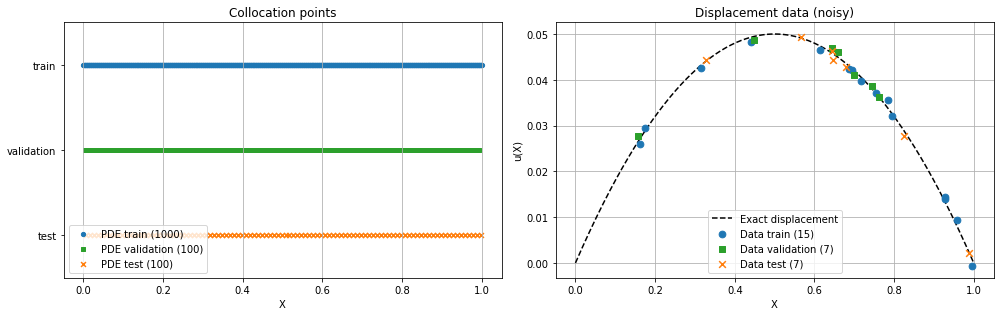

In [36]:
plot_data_split()


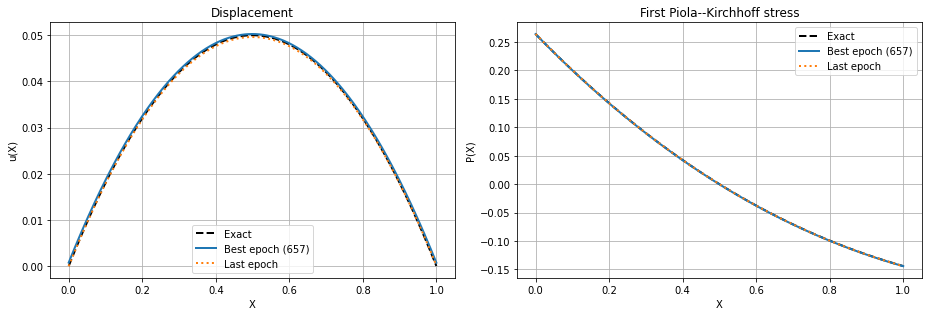

In [37]:
plot_solution()


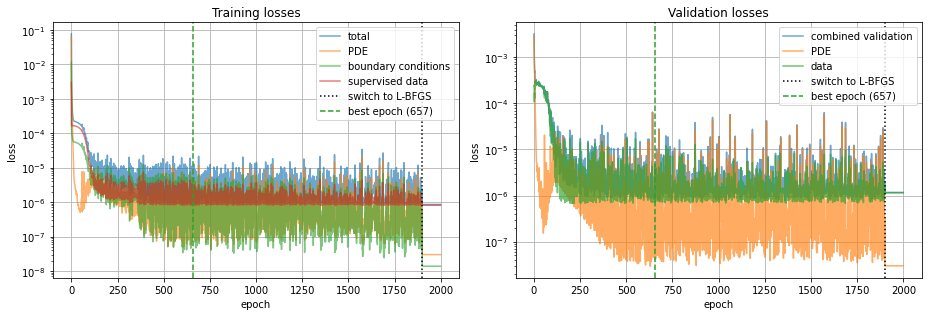

In [38]:
plot_losses()


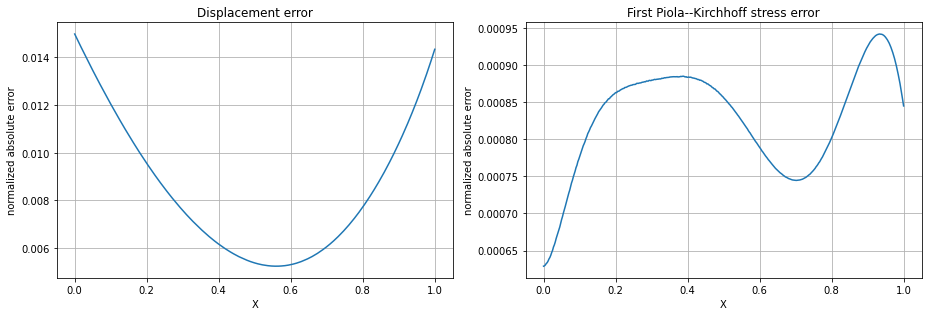

In [39]:
plot_errors()


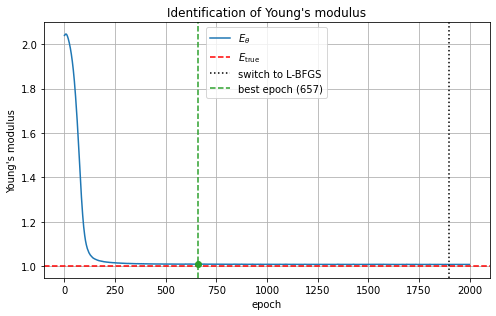

In [40]:
plot_identified_E()
